In [1]:
import sys, pathlib, numpy as np, torch
import matplotlib.pyplot as plt

config_file = pathlib.Path('/scorpio/home/yubei-stu-2/dreamerv3_torch_ver/configs.yaml')
CKPT_PATH = None  # None → 自动从 logdir 读 latest.pt；也可指定绝对路径

OVERRIDES = {                                     # 对应命令行 --key value
    "task":             "bouncing",        # 改成你的 task
    "act_mode":         "zero",                 # 改成你的 act_mode
    "logdir":           "/scorpio/home/yubei-stu-2/dreamerv3_torch_ver/logdir/",
    "offline_traindir": 'data/',    # 放 npz 的目录（带尾 /）
    "comment":          "slr",
    "nq":               7,
    "nv":               6,
}

In [2]:
# %% 1. imports & patt
sys.path.append('/scorpio/home/yubei-stu-2/dreamerv3_torch_ver/')
from ruamel.yaml import YAML
yaml = YAML(typ='safe', pure=True)

import tools, models
import gymnasium as gym

# %% 2. load config（和 main 里一样的方式）
# --------- 按需修改这几项 ----------
CONFIGS   = ["defaults", "dmc_proprio"]
configs = yaml.load(config_file.read_text())

def recursive_update(base, update):
    for k, v in update.items():
        if isinstance(v, dict) and k in base:
            recursive_update(base[k], v)
        else:
            base[k] = v

defaults = {}
for name in CONFIGS:
    recursive_update(defaults, configs[name])
recursive_update(defaults, OVERRIDES)

import argparse
parser = argparse.ArgumentParser()
for key, value in sorted(defaults.items(), key=lambda x: x[0]):
    arg_type = tools.args_type(value)
    parser.add_argument(f"--{key}", type=arg_type, default=arg_type(value))
config = parser.parse_args([])          # 空列表 → 全用 default

# %% 3. 构建 obs_space / act_space（从 main 里精简）
discrete_action = -1
if config.nq != 0:
    config.num_actions = 1
    action_space = gym.spaces.Box(-1, 1, dtype=np.float32)
    obs_space = gym.spaces.Dict({
        "position": gym.spaces.Box(-np.inf, np.inf, (config.nq,), dtype=np.float32),
        "velocity": gym.spaces.Box(-np.inf, np.inf, (config.nv,), dtype=np.float32),
    })
elif 'PandaPush' in config.task:
    config.num_actions = 3
    action_space = gym.spaces.Box(-1, 1, (3,), dtype=np.float32)
    obs_space = gym.spaces.Dict({'state': gym.spaces.Box(-np.inf, np.inf, (18,), dtype=np.float32)})
elif 'PandaStack' in config.task:
    config.num_actions = 4
    action_space = gym.spaces.Box(-1, 1, (4,), dtype=np.float32)
    obs_space = gym.spaces.Dict({'state': gym.spaces.Box(-np.inf, np.inf, (31,), dtype=np.float32)})
elif 'go' in config.task:
    discrete_action = config.num_actions = 361
    action_space = gym.spaces.Box(0, 1, (361,), dtype=np.float32)
    obs_space = gym.spaces.Dict({'state': gym.spaces.Box(-np.inf, np.inf, (363,), dtype=np.float32)})
elif 'Maze' in config.task:
    discrete_action = config.num_actions = 6
    action_space = gym.spaces.Box(0, 1, (6,), dtype=np.float32)
    obs_space = gym.spaces.Dict({'state': gym.spaces.Box(-np.inf, np.inf, (4,), dtype=np.float32)})
elif 'Point3D' in config.task:
    discrete_action = config.num_actions = 6
    action_space = gym.spaces.Box(0, 1, (6,), dtype=np.float32)
    obs_space = gym.spaces.Dict({'state': gym.spaces.Box(-np.inf, np.inf, (12,), dtype=np.float32)})
elif 'humanoid' in config.task:
    config.num_actions = 21
    action_space = gym.spaces.Box(-np.inf, np.inf, (21,), dtype=np.float32)
    obs_space = gym.spaces.Dict({'state': gym.spaces.Box(-np.inf, np.inf, (67,), dtype=np.float32)})
elif 'reacher' in config.task:
    config.num_actions = 2
    action_space = gym.spaces.Box(-np.inf, np.inf, (2,), dtype=np.float32)
    obs_space = gym.spaces.Dict({'state': gym.spaces.Box(-np.inf, np.inf, (6,), dtype=np.float32)})
else:
    discrete_action = config.num_actions = 18
    action_space = gym.spaces.Box(0, 1, (6,), dtype=np.float32)
    obs_space = gym.spaces.Dict({'state': gym.spaces.Box(0, 255, (128,), dtype=np.uint8)})



In [3]:
# %% 4. 构建 WorldModel & 加载权重
device = config.device
step = 0
wm = models.WorldModel(obs_space, action_space, step, config).to(device)

project_dir = f"{config.task}-{config.act_mode}-{config.comment}"
logdir = pathlib.Path(config.logdir + project_dir).expanduser()

ckpt_path = CKPT_PATH or (logdir / "best.pt")  # 优先 best，也可换 latest.pt
print("Loading checkpoint from:", ckpt_path)
checkpoint = torch.load(ckpt_path, map_location=device)

# Dreamer 保存的是整个 agent 的 state_dict，WorldModel 的 key 带 _wm. 前缀
wm_state = {k.replace("_wm.", "", 1): v for k, v in checkpoint["agent_state_dict"].items() if k.startswith("_wm.")}
wm.load_state_dict(wm_state)
wm.eval()
print("Model loaded.")

# %% 5. 加载 eval 数据（和 Dreamer.__init__ 里一致）
eval_path = config.offline_traindir + f"seq-{config.task}-{config.act_mode}-test.npz"
eval_data_np = np.load(eval_path)

if discrete_action != -1:
    action = eval_data_np['action'].squeeze()
    onehot = np.zeros((*action.shape, discrete_action), dtype=np.float32)
    idx = np.indices(action.shape)
    onehot[(*idx, action)] = 1
    eval_action = onehot
else:
    eval_action = eval_data_np['action'][:, :, None]

is_first = np.zeros_like(eval_data_np['action'][:, :, None])
is_first[:, 0] = 1

eval_data = {
    'actions':  torch.tensor(eval_action, device=device),
    'is_first': torch.tensor(is_first, device=device),
}
if 'humanoid' in config.task or 'reacher' in config.task:
    eval_data['actions'] = eval_data['actions'].to(torch.float32)

if config.nq != 0:
    eval_data['targets'] = {
        'position': torch.tensor(eval_data_np['obs'][:, :, :config.nq], device=device),
        'velocity': torch.tensor(eval_data_np['obs'][:, :, config.nq:], device=device),
    }
else:
    eval_data['targets'] = {
        'state': torch.tensor(eval_data_np['obs'], device=device, dtype=torch.float32),
    }
eval_target = torch.tensor(eval_data_np['obs'], device=device, dtype=torch.float32)

# %% 6. 跑 imagination
condition_steps = 10

with torch.no_grad():
    state_prediction, obs_rec_result = wm.propiro_pred(eval_data, condition_steps=condition_steps)

# state_prediction: [B, T-condition_steps, obs_dim]  → 对应 img_obs
# obs_rec_result:   [B, condition_steps, obs_dim]     → 对应 obs_rec（如果函数有返回的话）

img_obs = state_prediction                           # imagination 部分
eval_loss = torch.nn.MSELoss()(img_obs, eval_target[:, condition_steps:, :])
print(f"Eval MSE loss: {eval_loss.item():.6f}")

# %% 7. 准备 obs_rec
# 如果 propiro_pred 第二个返回值就是 reconstruction，直接用；
# 否则用 ground truth 的前 condition_steps 作为 obs_rec
if obs_rec_result is not None:
    obs_rec = obs_rec_result
else:
    obs_rec = eval_target[:, :condition_steps, :]
    print("propiro_pred 未返回 reconstruction，用 gt[:condition_steps] 代替")


encoder shape  {'position': (7,), 'velocity': (6,)}
Encoder CNN shapes: {}
Encoder MLP shapes: {'position': (7,), 'velocity': (6,)}
1
Decoder CNN shapes: {}
Decoder MLP shapes: {'position': (7,), 'velocity': (6,)}
opitmizer clip 1000
Optimizer model_opt has 16444685 variables.
Loading checkpoint from: /scorpio/home/yubei-stu-2/dreamerv3_torch_ver/logdir/bouncing-zero-slr/best.pt
Model loaded.
Eval MSE loss: 0.181583


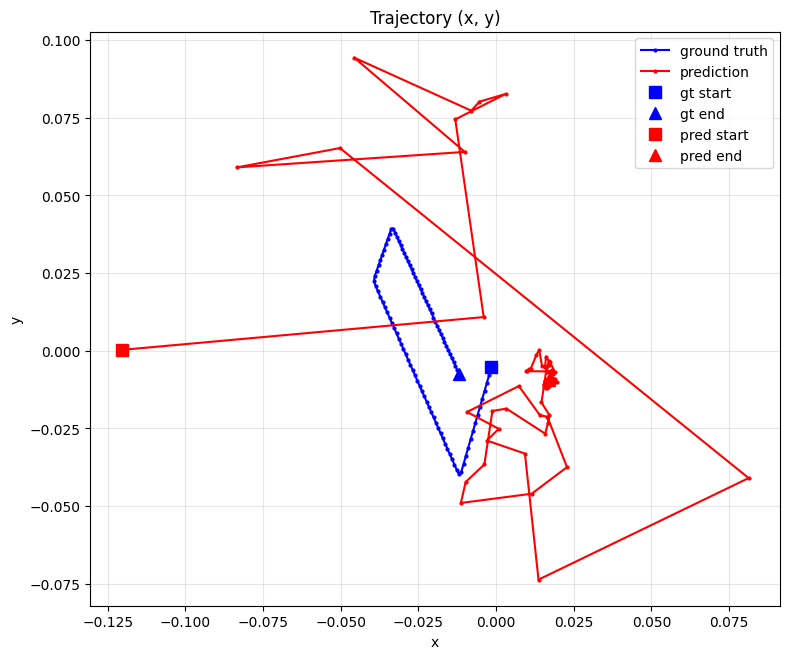

In [4]:
# %% 8. 可视化：(x, y) 轨迹图
traj_idx = 0

pred = np.concatenate((obs_rec[traj_idx].cpu().numpy(),
                        img_obs[traj_idx].cpu().numpy()), axis=0)
gt = eval_target[traj_idx, 1:].cpu().numpy()         # 和原来的 data['observations'][:, 1:] 对齐

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(gt[:, 0],   gt[:, 1],   'b-o', markersize=2, label='ground truth')
ax.plot(pred[:, 0],  pred[:, 1], 'r-o', markersize=2, label='prediction')

ax.plot(gt[0, 0],   gt[0, 1],   'bs', markersize=8, label='gt start')
ax.plot(gt[-1, 0],  gt[-1, 1],  'b^', markersize=8, label='gt end')
ax.plot(pred[0, 0], pred[0, 1], 'rs', markersize=8, label='pred start')
ax.plot(pred[-1, 0],pred[-1, 1],'r^', markersize=8, label='pred end')

ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Trajectory (x, y)')
ax.legend(); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [8]:
print(obs_rec[traj_idx].shape, img_obs[traj_idx].shape)

torch.Size([90, 1]) torch.Size([90, 13])
